In [11]:
import pandas as pd
import numpy as np
import requests
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, ccf, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, plot_ccf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

In [2]:
# Descarga de la serie de tiempo desde Banxico usando la API
BANXICO_TOKEN = '0c26688000f6b1ceb7ae7852d7f95599a495843728004bcc3f75c962eb17b02c'

series_dict = {
    'FIX': 'SF43718',
    'CETES_28': 'SF43936'
}

df_list = []
for nombre, serie in series_dict.items():
    url = f'https://www.banxico.org.mx/SieAPIRest/service/v1/series/{serie}/datos/2021-01-01/2026-03-04'
    res = requests.get(url, headers={'Bmx-Token': BANXICO_TOKEN})
    if res.status_code == 200:
        data = res.json()['bmx']['series'][0]['datos']
        df_temp = pd.DataFrame(data)
        df_temp['fecha'] = pd.to_datetime(df_temp['fecha'], format='%d/%m/%Y')
        df_temp['dato'] = pd.to_numeric(df_temp['dato'])
        df_temp.set_index('fecha', inplace=True)
        df_temp.columns = [nombre]
        df_list.append(df_temp)

df = pd.concat(df_list, axis=1)

# Asignar frecuencia de dias habiles y rellenar valores faltantes
df = df.asfreq('B').ffill().dropna()

In [3]:
# Visualizacion de las series originales
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=df.index, y=df['FIX'], name="FIX (MXN/USD)", line=dict(color='#005EB8')),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(x=df.index, y=df['CETES_28'], name="CETES 28 (%)", line=dict(color='#2ca02c', dash='dot')),
    secondary_y=True
)

fig.update_layout(
    title_text="Series Originales: Tipo de Cambio vs Tasa de Rendimiento",
    hovermode='x unified',
    template='plotly_white'
)
fig.update_yaxes(title_text="Pesos por Dolar", secondary_y=False)
fig.update_yaxes(title_text="Porcentaje (%)", secondary_y=True)

fig.show()

In [30]:
# Calculo de la media movil de 20 dias para visualizar la tendencia
df['Media_Movil'] = df['FIX'].rolling(window=20).mean()

# Grafica interactiva de la serie original y su media movil
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['FIX'], name="FIX Original", line=dict(color='#005EB8')))
fig.add_trace(go.Scatter(x=df.index, y=df['Media_Movil'], name="Media Movil (20 dias)", line=dict(color='#ff7f0e')))
fig.update_layout(title="Analisis de Estacionariedad - Serie Original", xaxis_title="Fecha", yaxis_title="Tipo de Cambio (FIX)", template="plotly_white")
fig.show()

# Prueba de Dickey-Fuller Aumentada (ADF) sobre la serie original
resultado_adf = adfuller(df['FIX'].dropna())
print("Prueba de Dickey-Fuller Aumentada (ADF) - Serie Original")
print(f"Estadistico ADF: {resultado_adf[0]:.4f}")
print(f"Valor p: {resultado_adf[1]:.4f}")

if resultado_adf[1] < 0.05:
    print("Conclusion: La serie original ES estacionaria.")
else:
    print("Conclusion: La serie original NO es estacionaria. Necesitaremos transformarla.")

Prueba de Dickey-Fuller Aumentada (ADF) - Serie Original
Estadistico ADF: -1.6863
Valor p: 0.4382
Conclusion: La serie original NO es estacionaria. Necesitaremos transformarla.


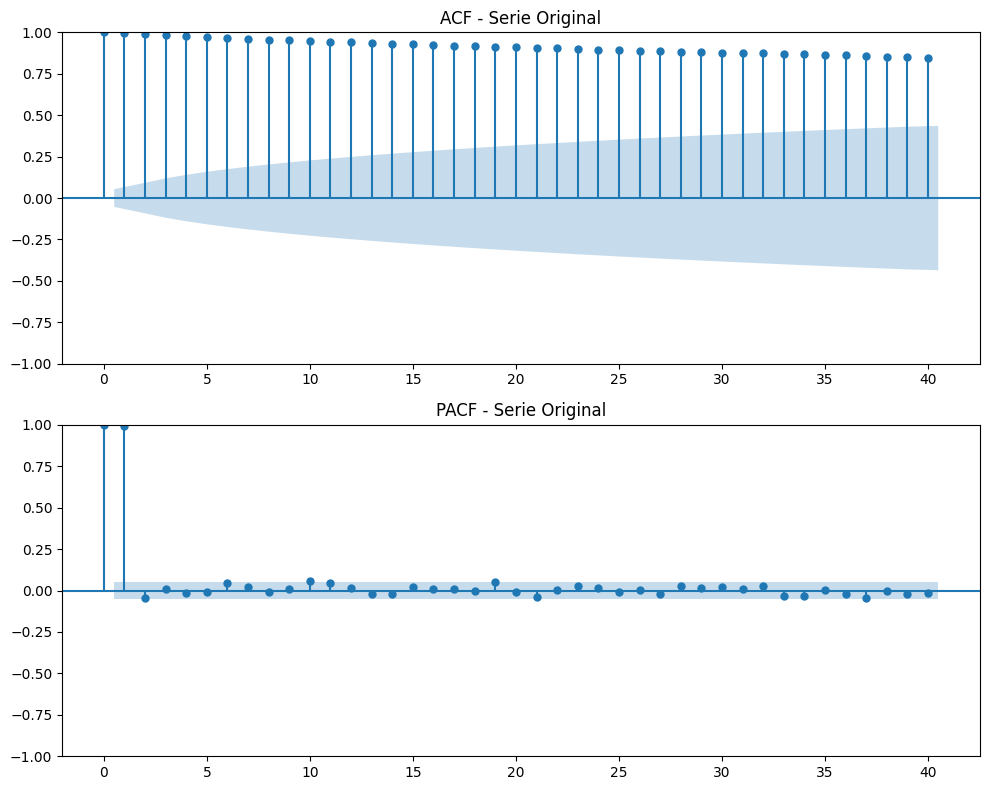

In [31]:
# Creacion de graficas de autocorrelacion para la serie original
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Autocorrelacion (ACF) - El decaimiento lento confirma la falta de estacionariedad
plot_acf(df['FIX'].dropna(), lags=40, ax=axes[0], title='ACF - Serie Original')

# Autocorrelacion Parcial (PACF)
plot_pacf(df['FIX'].dropna(), lags=40, ax=axes[1], title='PACF - Serie Original')

plt.tight_layout()
plt.show()

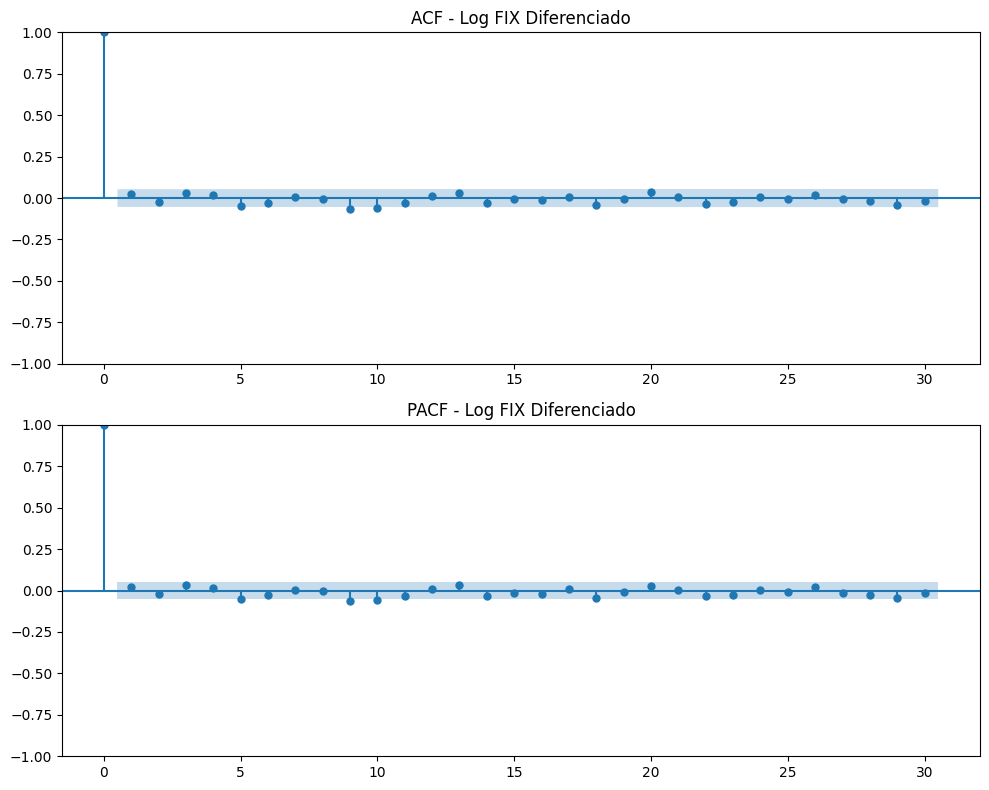

In [27]:
# Generacion de graficas para determinar los parametros AR y MA en la serie estacionaria
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# ACF de la serie logaritmica diferenciada para buscar el parametro q
plot_acf(df_diff['log_FIX'], lags=30, ax=axes[0], title="ACF - Log FIX Diferenciado")

# PACF de la serie logaritmica diferenciada para buscar el parametro p
plot_pacf(df_diff['log_FIX'], lags=30, ax=axes[1], title="PACF - Log FIX Diferenciado")

plt.tight_layout()
plt.show()

In [5]:
# Aplicacion de logaritmo para estabilizar la varianza
df['log_FIX'] = np.log(df['FIX'])
df['log_CETES'] = np.log(df['CETES_28'])

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("FIX Original", "Log FIX", "CETES 28 Original", "Log CETES"),
    vertical_spacing=0.15
)

fig.add_trace(go.Scatter(x=df.index, y=df['FIX'], line=dict(color='#005EB8')), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['log_FIX'], line=dict(color='#005EB8')), row=1, col=2)

fig.add_trace(go.Scatter(x=df.index, y=df['CETES_28'], line=dict(color='#2ca02c')), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['log_CETES'], line=dict(color='#2ca02c')), row=2, col=2)

fig.update_layout(height=600, showlegend=False, template='plotly_white', title_text="Efecto de la Transformacion Logaritmica")
fig.show()

In [6]:
# Extraccion de tendencia, estacionalidad y residuos de la serie en logaritmos
stl = STL(df['log_FIX'], period=5, robust=True)
res = stl.fit()

df_stl = pd.DataFrame({
    'Observado': df['log_FIX'],
    'Tendencia': res.trend,
    'Estacionalidad': res.seasonal,
    'Residuo': res.resid
})

fig = make_subplots(rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                    subplot_titles=("Observado (log_FIX)", "Tendencia", "Estacionalidad", "Residuos"))

colores = ['#005EB8', '#ff7f0e', '#2ca02c', '#d62728']
for i, col in enumerate(df_stl.columns):
    fig.add_trace(go.Scatter(x=df_stl.index, y=df_stl[col], name=col, line=dict(color=colores[i])), row=i+1, col=1)

fig.update_layout(height=800, title_text="Descomposicion STL", hovermode="x unified", template='plotly_white')
fig.show()

In [7]:
# Diferenciacion de las series para eliminar la tendencia y buscar estacionariedad
df_diff = df[['log_FIX', 'log_CETES']].diff().dropna()

# Funcion para ejecutar la prueba de Dickey-Fuller
def correr_adf(serie, nombre):
    resultado = adfuller(serie.dropna())
    print(f'Prueba ADF: {nombre}')
    print(f'Estadistico: {resultado[0]:.4f}')
    print(f'Valor p: {resultado[1]:.4f}')
    if resultado[1] < 0.05:
        print("La serie es estacionaria")
    else:
        print("La serie no es estacionaria")
    print("-" * 30)

correr_adf(df['log_FIX'], "Log FIX (Original)")
correr_adf(df_diff['log_FIX'], "Log FIX (Diferenciada)")

Prueba ADF: Log FIX (Original)
Estadistico: -1.6450
Valor p: 0.4597
La serie no es estacionaria
------------------------------
Prueba ADF: Log FIX (Diferenciada)
Estadistico: -35.6463
Valor p: 0.0000
La serie es estacionaria
------------------------------


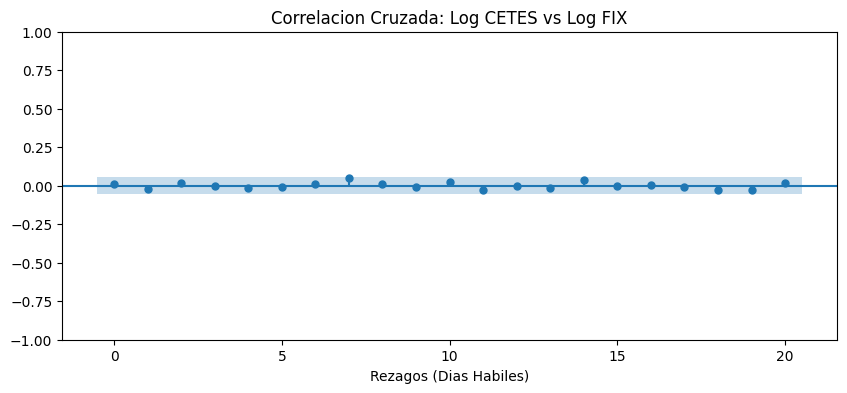

Prueba de Causalidad de Granger (5 dias habiles)
Log CETES afecta a Log FIX | Valor p (Rezago 5): 0.3355
No significativo estadisticamente a 5 rezagos bajo H0.


In [12]:
# Evaluacion de la relacion entre la variable exogena y la variable objetivo
fig, ax = plt.subplots(figsize=(10, 4))
plot_ccf(df_diff['log_CETES'], df_diff['log_FIX'], lags=20, ax=ax, alpha=0.05)
plt.title("Correlacion Cruzada: Log CETES vs Log FIX")
plt.xlabel("Rezagos (Dias Habiles)")
plt.show()

print("Prueba de Causalidad de Granger (5 dias habiles)")
datos_granger = df_diff[['log_FIX', 'log_CETES']]
resultado_granger = grangercausalitytests(datos_granger, maxlag=5, verbose=False)

valor_p = resultado_granger[5][0]['ssr_chi2test'][1]
print(f"Log CETES afecta a Log FIX | Valor p (Rezago 5): {valor_p:.4f}")

if valor_p < 0.05:
    print("Significativo: Los CETES aportan informacion al modelo.")
else:
    print("No significativo estadisticamente a 5 rezagos bajo H0.")

In [9]:
# Division de la base de datos en entrenamiento y prueba
fecha_corte = '2026-02-23'

df_train = df.loc[:fecha_corte]
df_test = df.loc['2026-02-24':]

print(f"Registros de entrenamiento: {len(df_train)}")
print(f"Registros de prueba: {len(df_test)}")

Registros de entrenamiento: 1338
Registros de prueba: 6


In [10]:
# Funcion para entrenar y evaluar distintas configuraciones de SARIMA y SARIMAX
def correr_modelo(df_entrenamiento, df_prueba, columna_objetivo, columna_exogena, p, d, q, P, D, Q, m, transformacion=None):
    y_train = df_entrenamiento[columna_objetivo].astype(float).copy()
    y_test  = df_prueba[columna_objetivo].astype(float).copy()

    X_train = df_entrenamiento[[columna_exogena]].astype(float).copy() if columna_exogena else None
    X_test  = df_prueba[[columna_exogena]].astype(float).copy() if columna_exogena else None

    if transformacion == 'log':
        y_train = np.log(y_train)

    modelo = SARIMAX(
        y_train,
        exog=X_train,
        order=(p, d, q),
        seasonal_order=(P, D, Q, m),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    ajuste = modelo.fit(disp=False)

    pronostico = ajuste.get_forecast(steps=len(y_test), exog=X_test)
    y_pred = pronostico.predicted_mean  
    y_pred = pd.Series(y_pred.values, index=y_test.index, name='forecast')

    if transformacion == 'log':
        y_pred = pd.Series(np.exp(y_pred.values), index=y_pred.index, name=y_pred.name)

    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae  = float(mean_absolute_error(y_test, y_pred))

    return {
        "y_train": y_train if transformacion != 'log' else pd.Series(np.exp(y_train.values), index=y_train.index),
        "y_test": y_test,
        "y_pred": y_pred,
        "rmse": rmse,
        "mae": mae
    }

def graficar_resultados(diccionario_resultados, titulo):
    fig = go.Figure()
    
    y_train_grafica = diccionario_resultados["y_train"].iloc[-30:]
    
    fig.add_trace(go.Scatter(x=y_train_grafica.index, y=y_train_grafica, mode='lines', name='Entrenamiento', line=dict(color='#005EB8')))
    fig.add_trace(go.Scatter(x=diccionario_resultados["y_test"].index, y=diccionario_resultados["y_test"], mode='lines', name='Real', line=dict(color='gray', dash='dot')))
    fig.add_trace(go.Scatter(x=diccionario_resultados["y_pred"].index, y=diccionario_resultados["y_pred"], mode='lines', name='Pronostico', line=dict(color='#d62728', width=2.5)))
    
    fig.update_layout(
        title=f"{titulo} | RMSE: {diccionario_resultados['rmse']:.4f} | MAE: {diccionario_resultados['mae']:.4f}",
        xaxis_title="Fecha", yaxis_title="Tipo de Cambio (FIX)",
        hovermode="x unified", template="plotly_white",
        height=500, width=900
    )
    fig.show()

# Parametros base
p, d, q = 1, 1, 1
P, D, Q, m = 1, 1, 1, 5  

print("Entrenando configuraciones del modelo...")

# Modelo 1: SARIMA Basico
res_basico = correr_modelo(df_train, df_test, columna_objetivo='FIX', columna_exogena=None, 
                     p=p, d=d, q=q, P=P, D=D, Q=Q, m=m, transformacion=None)
print(f"SARIMA Basico - RMSE: {res_basico['rmse']:.4f}, MAE: {res_basico['mae']:.4f}")

# Modelo 2: SARIMA con Transformacion Logaritmica
res_log = correr_modelo(df_train, df_test, columna_objetivo='FIX', columna_exogena=None, 
                     p=p, d=d, q=q, P=P, D=D, Q=Q, m=m, transformacion='log')
print(f"SARIMA Log - RMSE: {res_log['rmse']:.4f}, MAE: {res_log['mae']:.4f}")

# Modelo 3: SARIMAX con Variable Exogena (CETES)
res_sarimax = correr_modelo(df_train, df_test, columna_objetivo='FIX', columna_exogena='CETES_28', 
                         p=p, d=d, q=q, P=P, D=D, Q=Q, m=m, transformacion=None)
print(f"SARIMAX (CETES) - RMSE: {res_sarimax['rmse']:.4f}, MAE: {res_sarimax['mae']:.4f}")

graficar_resultados(res_basico, "1. SARIMA Basico")
graficar_resultados(res_log, "2. SARIMA Logaritmico")
graficar_resultados(res_sarimax, "3. SARIMAX con CETES")

Entrenando configuraciones del modelo...
SARIMA Basico - RMSE: 0.2169, MAE: 0.1339
SARIMA Log - RMSE: 0.2165, MAE: 0.1331
SARIMAX (CETES) - RMSE: 0.2173, MAE: 0.1344
